In [16]:
# SECTION 1: Load Processed Data and Assign Cluster Labels

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif
from sklearn.ensemble import StackingClassifier, ExtraTreesClassifier, GradientBoostingClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import confusion_matrix
from sklearn import set_config
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle
# Load processed features
df = pd.read_csv('processed_data.csv')
cluster1_df = df[df['Cluster'] == 1].copy()
df


,ROA(C) before interest and depreciation before interest,Operating Gross Margin,Cash flow rate,Net Value Per Share (B),Cash Flow Per Share,Debt ratio %,Fixed Assets Turnover Frequency,Operating profit per person,Working Capital to Total Assets,Cash/Total Assets,Cash/Current Liability,Total expense/Assets,Cash Flow to Total Assets,Cluster,Bankrupt?,Index
0,-1.168605,-1.573968,-0.436532,-0.325577,-0.574595,0.070964,-1.114032,-1.124689,-0.591218,-0.069704,0.274354,-0.425619,0.738928,0,0,0
1,0.574187,-0.034179,-0.065224,0.692715,0.248427,0.071891,-0.506348,0.392302,0.325295,-0.130996,-0.283515,-0.299274,0.407778,4,0,1
2,1.251907,0.554790,0.812446,0.783814,1.010382,0.036391,-0.619156,0.809168,0.521002,0.559842,0.618825,-0.319181,1.212510,3,0,2
3,-0.497809,-0.412254,-1.798833,-0.297918,-2.727776,1.978041,0.132113,1.014467,0.131558,-0.355639,-0.918414,-1.117056,0.392077,2,0,3
4,0.177827,-0.726740,-0.535725,0.482248,-0.418371,0.301855,0.532899,1.005835,-0.015705,1.184060,0.609289,0.634778,-1.108454,2,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5802,0.116941,-1.297989,-0.259765,-0.427976,0.342823,1.361753,-0.824933,0.203379,-1.746558,-0.930034,-1.259094,-0.937054,-0.223996,0,0,5802
5803,0.985923,2.160819,0.607066,0.033880,0.512061,-0.611996,1.710968,0.469603,0.180066,1.571653,1.156042,0.634038,1.221572,3,0,5803
5804,-0.284817,-1.211540,-0.077092,0.417002,0.447305,0.419741,0.814106,0.830234,1.159492,0.460858,0.009082,0.357083,0.272545,4,0,5804
5805,0.248628,2.092602,1.210137,-0.478025,1.256606,1.515605,0.593358,-0.608973,1.125224,1.616497,1.606391,2.215642,2.250804,3,0,5805


In [17]:
X_cluster1 = cluster1_df.drop(columns=['Bankrupt?', 'Cluster'])
y_cluster1 = cluster1_df['Bankrupt?']

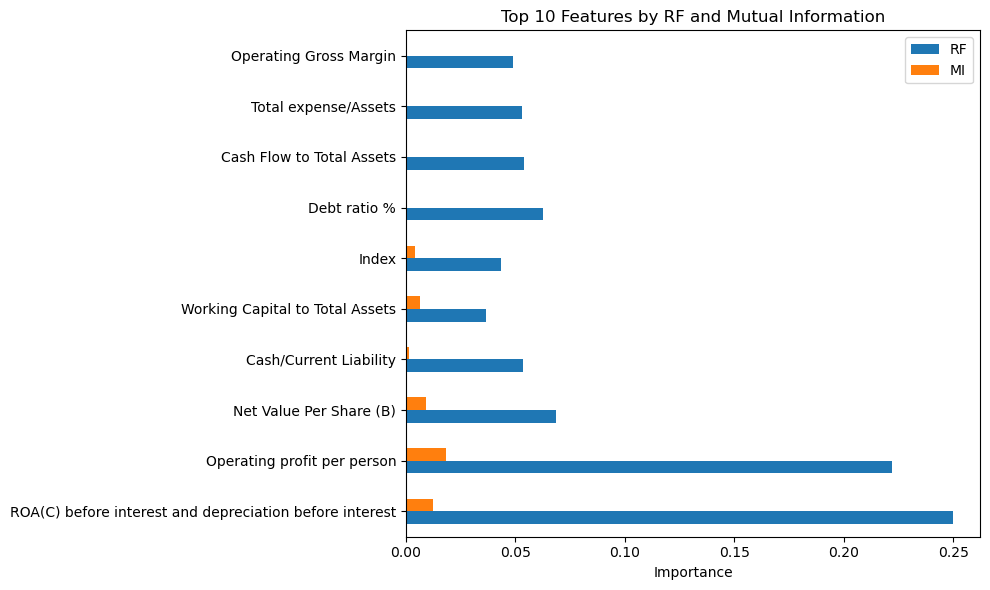

In [18]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_cluster1, y_cluster1)
rf_imp = pd.Series(rf.feature_importances_, index=X_cluster1.columns)
mi = mutual_info_classif(X_cluster1, y_cluster1, random_state=42)
mi_series = pd.Series(mi, index=X_cluster1.columns)
importances = pd.DataFrame({'RF': rf_imp, 'MI': mi_series})
importances['Combined'] = (importances.rank(ascending=False)['RF'] + importances.rank(ascending=False)['MI']) / 2
top10 = importances.sort_values('Combined').head(10)
top10[['RF', 'MI']].plot(kind='barh', figsize=(10, 6))
plt.title('Top 10 Features by RF and Mutual Information')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [19]:

# Select important 4 features manually
selected_features = [
    'Operating profit per person',
    'ROA(C) before interest and depreciation before interest',
    'Net Value Per Share (B)',
    'Working Capital to Total Assets'
]
X_selected = X_cluster1[selected_features]

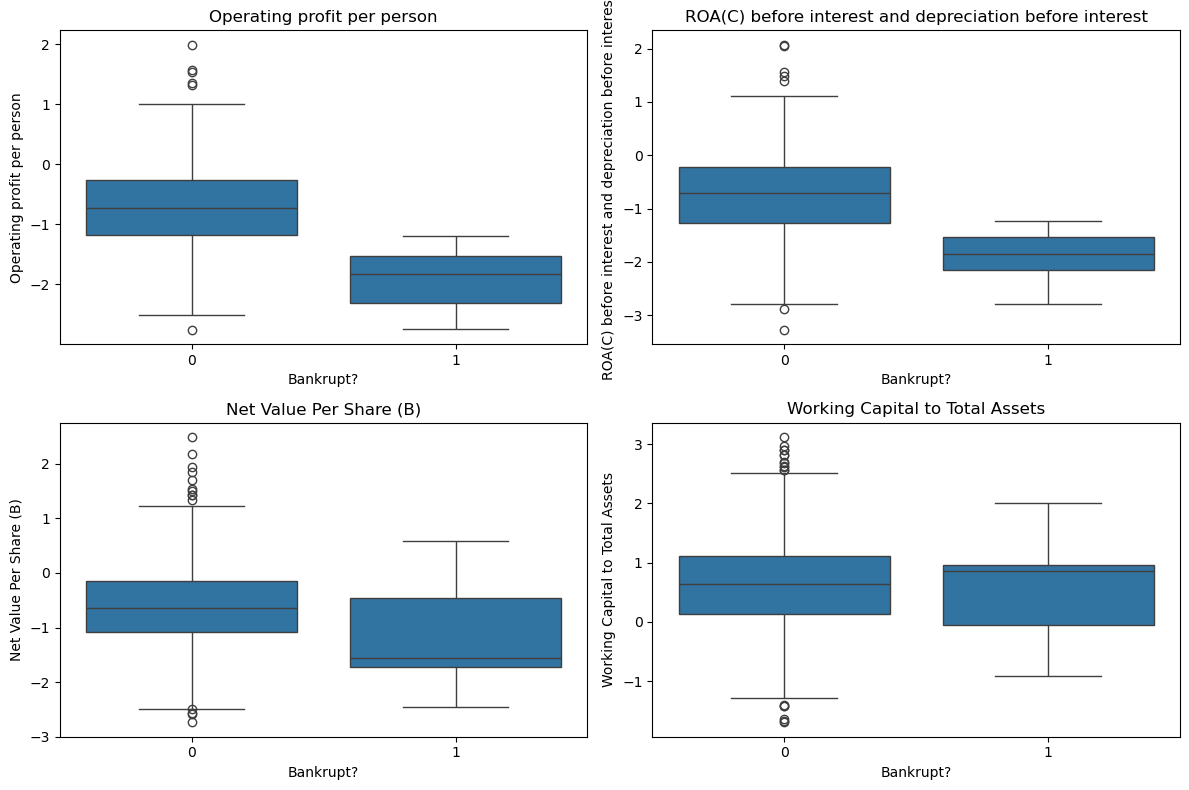

In [20]:
plt.figure(figsize=(12, 8))
for i, feat in enumerate(selected_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=cluster1_df, x='Bankrupt?', y=feat)
    plt.title(feat)
plt.tight_layout()
plt.show()

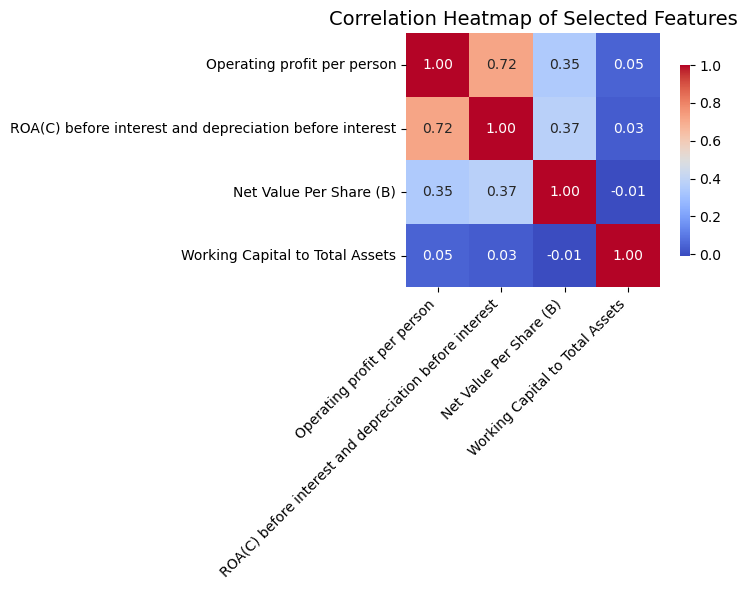

In [21]:
plt.figure(figsize=(8, 6))  # Set figure size

sns.heatmap(
    cluster1_df[selected_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True,
    cbar_kws={"shrink": .75}
)

plt.title('Correlation Heatmap of Selected Features', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10) 
plt.yticks(rotation=0, fontsize=10)              
plt.tight_layout()
plt.show()

In [22]:
# Save selected features
joblib.dump(selected_features, 'features.pkl')


['features.pkl']

In [23]:
# Split into 80-20 for model training
X_train, X_val, y_train, y_val = train_test_split(X_selected, y_cluster1, test_size=0.2, random_state=42, stratify=y_cluster1)

In [24]:
# Standard scaling on 80% train data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [25]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_cluster1[selected_features], y_cluster1)

In [26]:
scaler = StandardScaler()
X_smote_scaled = scaler.fit_transform(X_smote)

In [27]:
# Define base models
base_models = [
        ('bag', BaggingClassifier(random_state=42, n_estimators=300)),
        ('et', ExtraTreesClassifier(random_state=42, class_weight='balanced')),
        ('gb', GradientBoostingClassifier(random_state=42, n_estimators=300, max_depth=5)),
        ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
]

# Meta model
meta_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Create stacking classifier
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=cv
)
clf.fit(X_smote_scaled, y_smote)
y_val.train = clf.predict(X_train[selected_features])

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but BaggingClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but ExtraTreesClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [28]:
set_config(display='diagram')  
clf

StackingClassifier(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimators=[('bag',
                                BaggingClassifier(n_estimators=300,
                                                  random_state=42)),
                               ('et',
                                ExtraTreesClassifier(class_weight='balanced',
                                                     random_state=42)),
                               ('gb',
                                GradientBoostingClassifier(max_depth=5,
                                                           n_estimators=300,
                                                           random_state=42)),
                               ('knn',
                                KNeighborsClassifier(weights='distance'))],
                   final_estimator=LogisticRegression(class_weight='balanced',
                                                      max_iter=1000,
                                                      random_state=42))


Confusion Matrix for BG Base Model (Threshold = 0.3):
           Predicted 0    Predicted 1
Actual 0       810              21
Actual 1         0              11
Bankruptcy Accuracy (TP / (TP + FN)) for BG Base Model: 1.0000


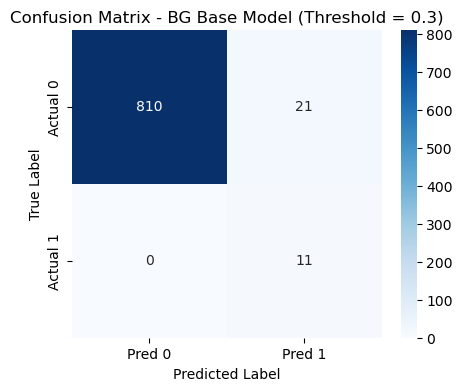


Confusion Matrix for Extra Trees Base Model (Threshold = 0.3):
           Predicted 0    Predicted 1
Actual 0       831               0
Actual 1         0              11
Bankruptcy Accuracy (TP / (TP + FN)) for Extra Trees Base Model: 1.0000


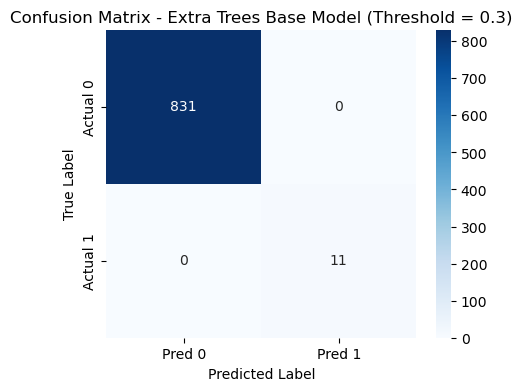


Confusion Matrix for Gradient Boosting Base Model (Threshold = 0.3):
           Predicted 0    Predicted 1
Actual 0       773              58
Actual 1         0              11
Bankruptcy Accuracy (TP / (TP + FN)) for Gradient Boosting Base Model: 1.0000


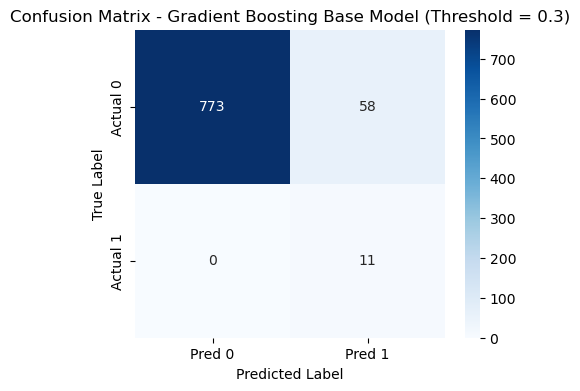


Confusion Matrix for KNN Base Model (Threshold = 0.3):
           Predicted 0    Predicted 1
Actual 0       831               0
Actual 1         0              11
Bankruptcy Accuracy (TP / (TP + FN)) for KNN Base Model: 1.0000


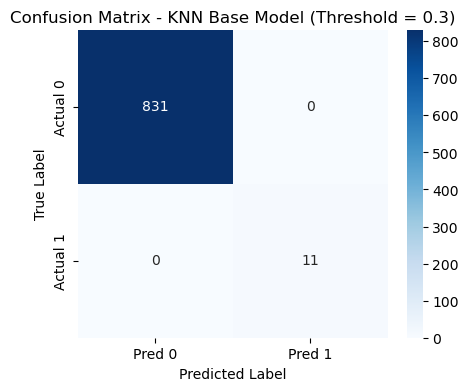


Confusion Matrix for Stacking Meta Model (Threshold = 0.3):
           Predicted 0    Predicted 1
Actual 0       831               0
Actual 1         0              11
Bankruptcy Accuracy (TP / (TP + FN)) for Stacking Meta Model: 1.0000


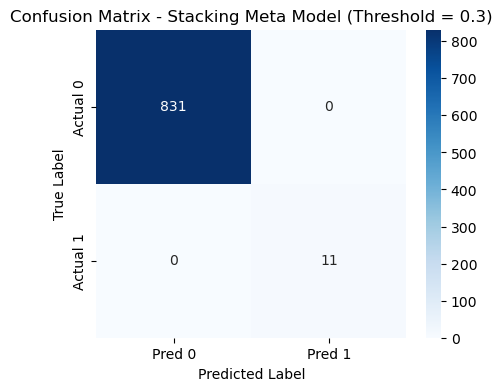

In [29]:
# Train base models separately for evaluation
bg = BaggingClassifier(random_state=42, n_estimators=300)
bg.fit(X_smote_scaled, y_smote)

kn = KNeighborsClassifier(n_neighbors=5, weights='distance')
kn.fit(X_smote_scaled, y_smote)

et = ExtraTreesClassifier(random_state=42, class_weight='balanced')
et.fit(X_smote_scaled, y_smote)

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_smote_scaled, y_smote)

# Ensure the stacking classifier is fitted
clf.fit(X_smote_scaled, y_smote)

# Scale full original data (X_selected)
X_full_scaled = scaler.transform(X_selected)

def evaluate_model(model, X, y_true, model_name="Model", threshold=0.30):
    # Get predicted probabilities
    y_pred_proba = model.predict_proba(X)[:, 1]
    # Apply custom threshold
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    if (tp + fn) > 0:
        bankruptcy_acc = tp / (tp + fn)
    else:
        bankruptcy_acc = 0

    print(f"\nConfusion Matrix for {model_name} (Threshold = {threshold}):")
    print(f"           Predicted 0    Predicted 1")
    print(f"Actual 0     {tn:5d}           {fp:5d}")
    print(f"Actual 1     {fn:5d}           {tp:5d}")
    print(f"Bankruptcy Accuracy (TP / (TP + FN)) for {model_name}: {bankruptcy_acc:.4f}")

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
    plt.title(f"Confusion Matrix - {model_name} (Threshold = {threshold})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

# Evaluate base models
evaluate_model(bg, X_full_scaled, y_cluster1, "BG Base Model")
evaluate_model(et, X_full_scaled, y_cluster1, "Extra Trees Base Model")
evaluate_model(gb, X_full_scaled, y_cluster1, "Gradient Boosting Base Model")
evaluate_model(kn, X_full_scaled, y_cluster1, "KNN Base Model")
# Evaluate Stacking Meta Model
evaluate_model(clf, X_full_scaled, y_cluster1, "Stacking Meta Model")


In [30]:
# Save final stacking model
joblib.dump(clf, 'stacking_model.pkl')

print("\nFinal stacking model, scaler, and features saved successfully.")


Final stacking model, scaler, and features saved successfully.


# Table 3 Summary for Submission

| Subgroup ID | Name | Base Models Avg Acc (TT(TF)) | Meta Model Acc (TT(TF)) | N_features |
|:-----------:|:----:|:----------------------------:|:-----------------------:|:----------:|
| 1           | Neel |      1.00[11(0)]        |       1.00[11(0)]   |    4      |
